# Word2Vec Embedding Evaluation
This notebook provides a simple and streamlined way to evaluate a trained Word2Vec model. It loads the learned embeddings and the corresponding vocabulary, and performs a set of basic qualitative checks to assess the quality of the representations.

In [25]:
from pathlib import Path
import sys
import numpy as np
from IPython.display import Image, display

In [26]:

# Ensure project src/ is on path when running the notebook
PROJECT_ROOT = Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))


# allow autoreloading of modules when they are edited outside the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First let's load the trained embeddings and the vocabulary

In [27]:
run_name = "train" 

run_dir = Path("output") / run_name


In [28]:
from src.model.word2vec import MyWord2Vec

emb_path = run_dir / f"embeddings_{run_name}.npz"

if not emb_path.exists():
    raise FileNotFoundError(f"Embedding file not found: {emb_path}")

model = MyWord2Vec.load(str(emb_path))
print(f"Loaded embeddings from {emb_path}")
print(f"Vocab size: {len(model.vocab)}, embedding dim: {model.embed_dim}")

Loaded embeddings from output/train/embeddings_train.npz
Vocab size: 36280, embedding dim: 100


We can visulize the loss curve of the training process to check if the model has converged properly

Final recorded loss: 2.4619
Number of recorded loss entries: 41


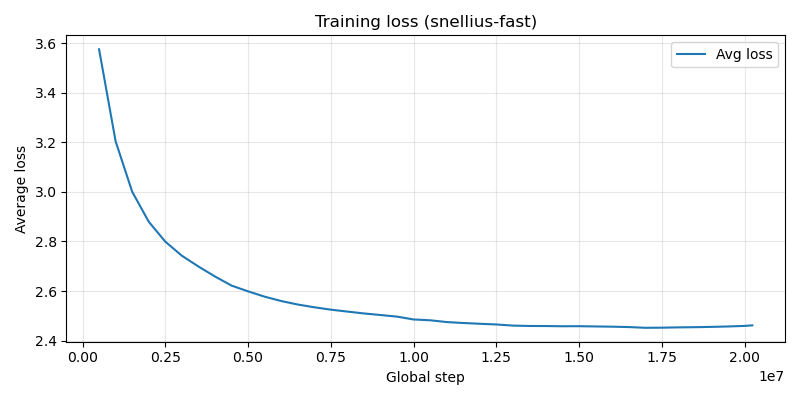

In [29]:
loss_npz = run_dir / f"loss_{run_name}.npz"
loss_png = run_dir / f"loss_{run_name}.png"

if loss_npz.exists():
    data = np.load(loss_npz)
    steps = data.get("steps")
    losses = data.get("losses")
    if losses is not None and len(losses) > 0:
        final_loss = float(losses[-1])
        print(f"Final recorded loss: {final_loss:.4f}")
        print("Number of recorded loss entries:", len(losses))
    else:
        print("Loss file found but contains no entries.")
else:
    print(f"Loss data not found at {loss_npz}")
    steps = losses = None

# display the loss plot if it exists
if loss_png.exists(): display(Image(filename=str(loss_png)))


# Qualitative Similarity Checks

We can perform some simple similarity lookups to see if the model has learned meaningful relationships between word

In [30]:
def show_similar(query: str, top_k: int = 10):
    try:
        sims = model.get_most_similar(query, top_k=top_k)
    
    except Exception as exc:
        print(f"Error for '{query}': {exc}")
        return
    
    for word, score in sims:
        print(f"{word:>15}  {score:.4f}")

In [31]:
queries = ["italy","computer", "king", "queen", "man", "woman"]

top_k = 10

for q in queries:
    print(f"\nTop {top_k} similar words to '{q}':")
    show_similar(q, top_k=top_k)


Top 10 similar words to 'italy':
          spain  0.9593
         poland  0.9473
         russia  0.9457
        ukraine  0.9425
        hungary  0.9424
          syria  0.9388
        england  0.9385
         turkey  0.9385
         serbia  0.9378
    switzerland  0.9368

Top 10 similar words to 'computer':
        digital  0.9279
       software  0.9127
          audio  0.8922
      computing  0.8919
         analog  0.8902
      microsoft  0.8884
      computers  0.8878
     electronic  0.8863
          video  0.8844
           unix  0.8838

Top 10 similar words to 'king':
           pope  0.9403
            iii  0.9312
        emperor  0.9277
           lord  0.9232
             iv  0.9167
    constantine  0.9101
      patriarch  0.9079
            son  0.9061
          queen  0.9012
           heir  0.8877

Top 10 similar words to 'queen':
      elizabeth  0.9360
       napoleon  0.9296
 constantinople  0.9248
     archbishop  0.9240
         bishop  0.9219
           heir  0.920

# Analogy Checks

We can also test the model's ability to solve word analogies of the form "a is to b as c is to ?"

In [32]:
examples = [
    ("king", "queen", "man"),
    ("paris", "france", "rome"),
    ("man", "woman", "brother"),
    ("italy", "rome", "france"),
    ("computer", "computers", "phone"),
]

for a, b, c in examples:
    print(f"\n'{a}' : '{b}' :: '{c}' : ?")
    try:
        for word, score in model.analogy(a, b, c, top_k=5):
            print(f"{word:>15}  {score:.4f}")
    except Exception as exc:
        print(f"  error: {exc}")


'king' : 'queen' :: 'man' : ?
            boy  0.9483
          woman  0.9413
         master  0.9381
          child  0.9316
          ghost  0.9295

'paris' : 'france' :: 'rome' : ?
          spain  1.0269
        britain  1.0002
         europe  0.9996
          egypt  0.9915
         greece  0.9833

'man' : 'woman' :: 'brother' : ?
      succeeded  1.0338
       murdered  1.0283
            ali  1.0170
          uncle  1.0131
           khan  1.0123

'italy' : 'rome' :: 'france' : ?
      jerusalem  0.8946
         persia  0.8922
          judah  0.8900
      conquered  0.8857
         romans  0.8843

'computer' : 'computers' :: 'phone' : ?
    radioactive  1.1323
         assets  1.1258
        planets  1.1256
        colours  1.1245
        varying  1.1234
